# Разведовательный анализ данных 

### Описание курсовой работы 

**Тема проекта:** Прогнозирование спроса на такси/каршеринг по районам 
**Описание:** В рамках проекта студенты будут прогнозировать спрос на такси/каршеринг в различных районах Москвы. Для этого предстоит проанализировать исторические данные, изучить влияние временных и погодных факторов, а также использовать данные о географическом расположении. В проекте будет применяться анализ пространственно-временных данных, методы машинного обучения, а также — визуализация результатов на интерактивных картах.

Описание признаков находится в файле dataset.md.

**Состав участников:** Клаузер Андрей Сергеевич, Давлетов Руслан Салаватович, Бутылин Максим Дмитриевич, Елисеева Александра Николаевна, Наумова Евгения Ильинична.

### 0. Описание данных


| Поле                   | Тип данных         | Описание                                    |
|------------------------|------------------|--------------------------------------------|
| `timestamp`           | datetime64[ns]   | Метка времени, соответствующая периоду наблюдений |
| `district_name`       | object           | Название района                     |
| `administrative_region`  | object  | Название административного округа           |
| `lat`                | float64          | Широта центра района                       |
| `lon`                | float64          | Долгота центра района                      |
| `n_taxi_start`       | int64          | Количество поездок на такси, начавшихся в районе |
| `n_taxi_end`         | int64          | Количество поездок на такси, завершившихся в районе |
| `n_carsharing_start` | int64          | Количество поездок на каршеринге, начавшихся в районе |
| `n_carsharing_end`   | int64          | Количество поездок на каршеринге, завершившихся в районе |
| `temperature`        | float64          | Температура воздуха (°C) на момент наблюдений |
| `precipitation`      | float64          | Количество осадков (мм) на момент наблюдений |
| `humidity`          | int64          | Влажность воздуха (%) на момент наблюдений |
| `wind_speed`         | float64          | Скорость ветра (м/с) на момент наблюдений |
| `weather_code`       | int64          | Код типа погоды согласно метеоданным       |
| `rush_hour`       | int64          | Час пик       |
| `season`       | int64          | Сезон (зима/весна/лето/осень)       |
| `is_holiday_or_weekend`       | int64          | Выходной день / праздник       |
| `quarter`       | object          | Номер квартала       |
| `station_load`       | int64          | Степень загруженности метро    |
| `station_load_norm`       | float64          | Степень загруженности метро нормализованная   |
| `number_of_stations`       | int64          | Количество станций метро по районам   |
| `number_of_places`       | int64          | Общее количество популярных локаций по районам  |
| `population_district_2023`   | int      | Население района на 2023 год       |
| `population_near_metro`   | float64      | Доля населения проживащее в близости от станций метро       |
| `price_m2`   | float64      | Стоимость квадратного метра на вторичном рынке, тыс.руб       |


Код состояния погоды (**weather_code**) в принимает значения от **1 до 25**, а также **NaN** для отсутствующих данных. Эти значения соответствуют различным погодным явлениям, таким как типы осадков, облачность, видимость и другие метеорологические явления:

| Код | Погодное условие         |
|-----|--------------------------|
| 1   | Ясно                    |
| 2   | Солнечно                 |
| 3   | Облачно                  |
| 4   | Пасмурно                 |
| 5   | Туман                    |
| 6   | Ледяной туман            |
| 7   | Легкий дождь             |
| 8   | Дождь                    |
| 9   | Сильный дождь            |
| 10  | Ледяной дождь            |
| 11  | Сильный ледяной дождь    |
| 12  | Дождь со снегом          |
| 13  | Сильный дождь со снегом  |
| 14  | Легкий снегопад          |
| 15  | Снегопад                 |
| 16  | Сильный снегопад         |
| 17  | Дождевой ливень          |
| 18  | Сильный дождевой ливень  |
| 19  | Дождь со снегом (ливень) |
| 20  | Сильный дождь со снегом  |
| 21  | Снежный ливень           |
| 22  | Сильный снежный ливень   |
| 23  | Молния                   |
| 24  | Град                     |
| 25  | Гроза                    |
| **NaN** | Нет данных           |


### 1. Загрузка данных

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Выведем все поля
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

#Загружаем основной датасет
main_df = pd.read_csv('main_df.csv', parse_dates=['timestamp'])
main_df.head()

,timestamp,district_name,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,station_load_norm,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2,administrative_region
0,2024-01-01 00:00:00,Академический район,55.689537,37.576881,203,178,15,21,-11.1,0.0,68,11.0,4,0,0,1,I квартал,6,0.511902,1,123,117048,0.717789,317.4,Юго-Западный
1,2024-01-01 01:00:00,Академический район,55.689537,37.576881,417,355,11,14,-12.0,0.0,75,7.4,4,0,0,1,I квартал,6,0.511902,1,123,117048,0.717789,317.4,Юго-Западный
2,2024-01-01 02:00:00,Академический район,55.689537,37.576881,404,426,5,9,-12.4,0.0,76,5.5,4,0,0,1,I квартал,6,0.511902,1,123,117048,0.717789,317.4,Юго-Западный
3,2024-01-01 03:00:00,Академический район,55.689537,37.576881,381,415,6,6,-12.1,0.0,73,11.0,4,0,0,1,I квартал,6,0.511902,1,123,117048,0.717789,317.4,Юго-Западный
4,2024-01-01 04:00:00,Академический район,55.689537,37.576881,281,332,4,4,-12.7,0.0,70,7.4,14,0,0,1,I квартал,6,0.511902,1,123,117048,0.717789,317.4,Юго-Западный


In [38]:
# Основная ифнформация о датасете
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156320 entries, 0 to 1156319
Data columns (total 25 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   timestamp                 1156320 non-null  datetime64[ns]
 1   district_name             1156320 non-null  object        
 2   lat                       1156320 non-null  float64       
 3   lon                       1156320 non-null  float64       
 4   n_taxi_start              1156320 non-null  int64         
 5   n_taxi_end                1156320 non-null  int64         
 6   n_carsharing_start        1156320 non-null  int64         
 7   n_carsharing_end          1156320 non-null  int64         
 8   temperature               1156320 non-null  float64       
 9   precipitation             1156320 non-null  float64       
 10  humidity                  1156320 non-null  int64         
 11  wind_speed                1156320 non-null  float6

**Вывод:** все поля преобразованы и имеют правильный формат данных. 

In [39]:
# Узнаем размер датасета
a, b = main_df.shape

print (f'Вывод: размер датасета: {a} строк и {b} столбцов')

Вывод: размер датасета: 1156320 строк и 25 столбцов


### 2. Предобработка данных

- Есть ли пропуски в данных? Какой процент они составляют от числа строк? Почему они могли появиться? Если есть пропуски, выберите способ обработки пропусков для каждого столбца. Расскажите, почему выбрали именно этот способ. Обработайте пропуски.
- Соответствуют ли типы данных в датасете тем, которые нужны (например, есть ли возраст в формате строки)? Исправьте это, если да.

In [40]:
# Выведем процент пропусков по столбцам
pd.DataFrame(round(main_df.isna()\
                          .mean() * 100, 1))

,0
timestamp,0.0
district_name,0.0
lat,0.0
lon,0.0
n_taxi_start,0.0
n_taxi_end,0.0
n_carsharing_start,0.0
n_carsharing_end,0.0
temperature,0.0
precipitation,0.0


**Вывод:** в данных отсутствуют пропуски, так как данные агрегированы до дня, часа, района Москвы. Но в данных есть много нулей, проверим их. 

In [41]:
# Проверяем данные на явые дубликаты
print (f'Вывод: в наборе данных - {main_df.duplicated().sum()} явных дубликатов')

Вывод: в наборе данных - 0 явных дубликатов


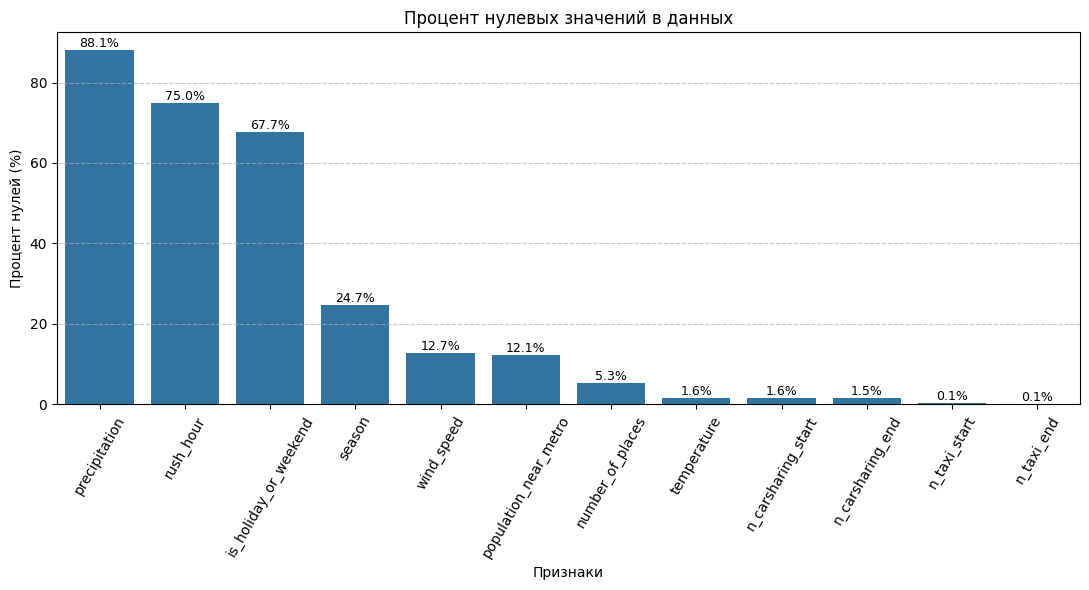

In [45]:
zero_value_percentage = (main_df == 0).mean() * 100

columns_with_zeros = zero_value_percentage[zero_value_percentage > 0].sort_values(ascending=False)

plt.figure(figsize=(11, 6))
bar_plot = sns.barplot(x=columns_with_zeros.index, y=columns_with_zeros.values)

plt.xticks(rotation=60, fontsize=10)
plt.title('Процент нулевых значений в данных', fontsize=12)
plt.ylabel('Процент нулей (%)', fontsize=10)
plt.xlabel('Признаки', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bar_plot.patches:
    bar_plot.annotate(f'{bar.get_height():.1f}%', 
                      (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                      ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.tight_layout()
plt.show()

Вывод:

- Нулевые значения показывают, что в 88% дней не было осадков.
- Пиковыми часами выбраны 6 часов в течение дня, что приводит к тому, что 25% часов имеют нулевые значения.
- Переменная "выходные" представлена в виде булевого значения, где 0 соответствует будним дням.
- Переменная "сезон" является категориальной и также содержит 0, что объясняет наличие 25% нулевых значений.
- Скорость ветра демонстрирует нормальное количество нулевых значений.
- В некоторых районах отсутствуют станции метро и развлекательные заведения.
- В течение года наблюдаются периоды с нулевыми значениями погоды.

Статистически значимыми являются переменные, связанные со стартом и окончанием поездок на каршеринге и такси. 1.5% данных по каршерингу и 0.1% данных по такси имеют нулевые значения, что может происходить в крайних случаях. Рекомендуется исключить эти строки из анализа.

In [11]:
# Проверим типы данных в датасете
main_df.dtypes

timestamp                   datetime64[ns]
district_name                       object
lat                                float64
lon                                float64
n_taxi_start                         int64
n_taxi_end                           int64
n_carsharing_start                   int64
n_carsharing_end                     int64
temperature                        float64
precipitation                      float64
humidity                             int64
wind_speed                         float64
weather_code                         int64
rush_hour                            int64
season                               int64
is_holiday_or_weekend                int64
quarter                             object
station_load                         int64
station_load_norm                  float64
number_of_stations                   int64
number_of_places                     int64
population_district_2023             int64
population_near_metro              float64
price_m2   

**Вывод:** все типы соответствуют необходимым.

### 3. Описательная статистика

1. Посчитайте описательные статистики по всем переменным.
2. Изучите каждый признак. Какие значения он принимает? 
    - для числовых признаков - диапазон значений
    - для категориальных - уникальные значения
3. Есть ли в данных выбросы или ошибки (например, отрицательная цена)? Как вы их определяете? Обработайте выбросы


#### Количественные переменные 

##### Количество поездок на такси, начавшихся в районе

In [12]:
# Выводим описательные статистики
main_df['n_taxi_start'].describe().round(2)

count    1156320.00
mean         272.87
std          248.48
min            0.00
25%          105.00
50%          217.00
75%          354.00
max         3895.00
Name: n_taxi_start, dtype: float64

In [46]:
main_df['n_taxi_start'].sum()

315528187

**Вывод:** 
Общее количество поездок - 315 528 187. Среднее количество поездок составляет 272.87, однако стандартное отклонение в 248.48 указывает на значительные колебания в данных. Минимальное значение (0) говорит о том, что в некоторые дни не было поездок **(но это выглядит очень подозрительно, скорее всего это ошибки в загрузке)**, в то время как максимальное значение (3895) указывает на дни с очень высокой активностью. Квартильные значения показывают, что 25% дней имеют менее 105 поездок, а 75% — менее 354. 

In [14]:
# Посмотрим сколько строк с числом такси равным 0
a = main_df[main_df['n_taxi_start'] == 0].shape[0]

print (f'Вывод: в наборе данных - {a} ({(round(a / main_df.shape[0] * 100 , 2))}%) строк с числом такси равным 0')

Вывод: в наборе данных - 1584 (0.14%) строк с числом такси равным 0


##### Количество поездок на такси, завершившихся в районе

In [15]:
# Выводим описательные статистики
main_df['n_taxi_end'].describe().round(2)

count    1156320.00
mean         271.70
std          258.66
min            0.00
25%          108.00
50%          213.00
75%          340.00
max         4519.00
Name: n_taxi_end, dtype: float64

In [47]:
main_df['n_taxi_end'].sum()

314173735

**Вывод:** 
Общее количество поездок - 314 173 735. Среднее количество поездок составляет 271.7, однако стандартное отклонение в 258.66 указывает на значительные колебания в данных. Минимальное значение (0) говорит о том, что в некоторые дни не было поездок **(но это выглядит очень подозрительно, скорее всего это ошибки в загрузке)**, в то время как максимальное значение (4519) указывает на дни с очень высокой активностью. Квартильные значения показывают, что 25% дней имеют менее 108 поездок, а 75% — менее 340. 

In [ ]:
# Посмотрим сколько строк с числом такси равным 0
a = main_df[main_df['n_taxi_end'] == 0].shape[0]

print (f'Вывод: в наборе данных - {a} ({(round(a / main_df.shape[0] * 100 , 2))}%) строк с числом такси равным 0')

Вывод: в наборе данных - 1201 (0.1%) строк с числом такси равным 0


Стоит обратить внимание, что число стартаваших и окончавших поездок разнится. 

##### Количество поездок на каршеринге, начавшихся в районе

In [16]:
# Выводим описательные статистики
main_df['n_carsharing_start'].describe().round(2)

count    1156320.00
mean          33.72
std           27.62
min            0.00
25%           12.00
50%           29.00
75%           48.00
max          301.00
Name: n_carsharing_start, dtype: float64

**Вывод:**
- В среднем пользователи совершают около 34 поездок, с высоким стандартным отклонением (27.62), что указывает на разнообразие в активности.
- Минимальное количество поездок равно 0, что говорит о пользователях, не использующих каршеринг или возможных пропусках в данных. 
- 25% пользователей совершили 12 или менее поездок, что свидетельствует о низкой активности значительной части клиентов.
- Медиана в 29 поездок показывает, что половина пользователей использует каршеринг менее активно, чем средний пользователь.

In [50]:
# Посмотрим сколько строк с числом каршеринга равным 0
a = main_df[main_df['n_carsharing_start'] == 0].shape[0]

print (f'Вывод: в наборе данных - {a} ({(round(a / main_df.shape[0] * 100 , 2))}%) строк с числом каршеринга равным 0')

Вывод: в наборе данных - 18375 (1.59%) строк с числом каршеринга равным 0


##### Количество поездок на каршеринге, завершившихся в районе

In [17]:
# Выводим описательные статистики
main_df['n_carsharing_end'].describe().round(2)

count    1156320.00
mean          33.67
std           27.60
min            0.00
25%           12.00
50%           29.00
75%           47.00
max          305.00
Name: n_carsharing_end, dtype: float64

**Вывод:**
- В среднем пользователи завершают около 34 поездок, что близко к значению для стартовавших поездок.
- Стандартное отклонение в 27.60 свидетельствует о значительном разнообразии в количестве завершенных поездок среди пользователей.
- Минимальное значение в 0 показывает, что может указывать на неактивных клиентов или пропуски в данных. 
- Максимальное количество завершенных поездок составляет 305.
- 25% пользователей завершили 12 или менее поездок, что может указывать на необходимость улучшения вовлеченности менее активных клиентов.

In [52]:
# Посмотрим сколько строк с числом каршеринга равным 0
a = main_df[main_df['n_carsharing_end'] == 0].shape[0]

print (f'Вывод: в наборе данных - {a} ({(round(a / main_df.shape[0] * 100 , 2))}%) строк с числом каршеринга равным 0')

Вывод: в наборе данных - 17448 (1.51%) строк с числом каршеринга равным 0


##### Температура воздуха (°C) на момент наблюдений

In [18]:
# Выводим описательные статистики
main_df['temperature'].describe().round(2)

count    1156320.00
mean           7.87
std           11.33
min          -31.40
25%           -0.20
50%            7.60
75%           17.50
max           35.00
Name: temperature, dtype: float64

**Выводы:**
- Средняя температура составляет 7.87°C, что указывает на умеренно холодный климат.
- Стандартное отклонение в 11.33°C свидетельствует о значительных колебаниях температуры, что связано с сезонными изменениями.
- Минимальная температура зафиксирована на уровне -31.40°C.
- Максимальная температура достигает 35.00°C.

##### Количество осадков (мм) на момент наблюдений

In [19]:
# Выводим описательные статистики
main_df['precipitation'].describe().round(2)

count    1156320.00
mean           0.07
std            0.38
min            0.00
25%            0.00
50%            0.00
75%            0.00
max           11.90
Name: precipitation, dtype: float64

**Выводы:**

- Среднее количество осадков составляет 0.07 мм, что указывает на преобладание сухих условий.
- 75% наблюдений имеют значение 0.00 мм, что подтверждает, что большинство дней были без осадков.
- Максимальное значение осадков составляет 11.90 мм, что указывает на редкие, но возможные сильные дожди.
- Стандартное отклонение в 0.38 мм говорит о небольших вариациях в количестве осадков.

##### Влажность воздуха (%) на момент наблюдений

In [20]:
# Выводим описательные статистики
main_df['humidity'].describe().round(2)

count    1156320.00
mean          73.20
std           17.36
min           20.00
25%           61.00
50%           77.00
75%           87.00
max          100.00
Name: humidity, dtype: float64

**Выводы:** 
- Средняя влажность составляет 73.20%, что указывает на относительно высокую влажность в рассматриваемый период.
- Стандартное отклонение в 17.36% свидетельствует о значительных колебаниях влажности, что может быть связано с изменениями погоды.
- Минимальное значение влажности равно 20.00%, что указывает на возможные сухие условия в определенные дни.
- 75% наблюдений имеют влажность ниже 87.00%, что говорит о том, что большинство дней характеризуются высокой влажностью.
- Максимальная влажность достигает 100.00%, что указывает на полное насыщение воздуха влагой, что может происходить в условиях дождя или тумана.

##### Скорость ветра (м/с) на момент наблюдений

In [21]:
# Выводим описательные статистики
main_df['wind_speed'].describe().round(2)

count    1156320.00
mean           7.11
std            6.54
min            0.00
25%            3.60
50%            5.50
75%           10.80
max           47.00
Name: wind_speed, dtype: float64

**Выводы:** 
- Средняя скорость ветра составляет 7.11 м/с, что указывает на умеренные условия ветра в рассматриваемый период.
- Стандартное отклонение в 6.54 м/с свидетельствует о значительных колебаниях скорости ветра, что означать, что в некоторые дни ветер был значительно сильнее или слабее среднего значения.
- Минимальное значение скорости ветра равно 0.00 м/с, что указывает на наличие дней без ветра.
- Максимальная скорость ветра достигает 47.00 м/с.
- Квартильные значения показывают, что 25% наблюдений имеют скорость ветра ниже 3.60 м/с, а 75% — ниже 10.80 м/с.

##### Количество станций метро по районам

In [22]:
# Выводим описательные статистики
main_df['number_of_stations'].describe().round(2)

count    1156320.00
mean           2.45
std            1.70
min            1.00
25%            1.00
50%            2.00
75%            3.00
max           14.00
Name: number_of_stations, dtype: float64

**Выводы:** 
- Среднее количество станций составляет 2.45, что указывает на то, что в среднем в районе имеется чуть более двух станций метро.
- Стандартное отклонение в 1.70 говорит о том, что количество станций варьируется, и в некоторых районах может быть значительно больше или меньше станций по сравнению со средним значением.
- Минимальное значение равно 1.00, что показывает наличие метро во всех районах Москвы. 
- Максимальное значение достигает 14.00.
- Квартильные значения показывают, что 25% районов имеют 1 станцию, 50% — 2 станции, а 75% — 3 станции. Это говорит о том, что большинство районов имеют небольшое количество станций, и лишь небольшая часть районов имеет более трех станций.

##### Общее количество популярных локаций по районам

In [23]:
# Выводим описательные статистики
main_df['number_of_places'].describe().round(2)

count    1156320.00
mean          77.20
std           93.75
min            0.00
25%           19.00
50%           38.50
75%           84.50
max          300.00
Name: number_of_places, dtype: float64

**Выводы:** 
- Среднее количество популярных локаций составляет 77.20, что указывает на то, что в среднем в районе имеется около 77 популярных мест (кино, развлекательные центры, кафе и др.).
- Стандартное отклонение в 93.75 говорит о значительных колебаниях в количестве популярных локаций между районами.
- Минимальное значение равно 0.00, что указывает на наличие районов, где нет популярных локаций. Это может быть связано с низкой плотностью населения или недостаточной развитостью инфраструктуры, а также в проблемах с данными. 
- Максимальное значение достигает 300.00, что свидетельствует о наличии районов с очень большим количеством популярных локаций, но стоит обратить внимание, что ограничение по API тоже равно 300, поэтому необходимо проверить данные по текущим районам. 
- Квартильные значения показывают, что 25% районов имеют 19 популярных локаций, 50% — 38.50, а 75% — 84.50. Это говорит о том, что большинство районов имеют относительно небольшое количество популярных мест, в то время как лишь небольшая часть районов имеет более 84 локаций.

##### Население района на 2023 год

In [24]:
# Выводим описательные статистики
main_df['population_district_2023'].describe().round(2)

count    1156320.00
mean       93591.27
std        43837.80
min         9113.00
25%        67575.00
50%        95660.00
75%       115648.50
max       255044.00
Name: population_district_2023, dtype: float64

**Выводы:** 
- Среднее население составляет 93,591.27 человек, что указывает на то, что в среднем в районе проживает около 94 тысяч человек.
- Стандартное отклонение в 43,837.80 говорит о значительных различиях в численности населения между районами. Это означает, что в некоторых районах население может быть значительно выше или ниже среднего значения.
- Минимальное значение равно 9,113 человек, что указывает на наличие районов с относительно небольшим населением, возможно, это менее развитые или удаленные районы.
- Максимальное значение достигает 255,044 человек, что свидетельствует о наличии очень густонаселенных районов, возможно, это центральные или экономически развитые зоны.
- Квартильные значения показывают, что 25% районов имеют население ниже 67,575 человек, 50% (медиана) — 95,660 человек, а 75% — 115,648.50 человек. Это говорит о том, что большинство районов имеют население выше 67 тысяч, но менее 116 тысяч, что может указывать на наличие как малонаселенных, так и более густонаселенных районов.

##### Доля населения проживащее в близости от станций метро

In [25]:
# Выводим описательные статистики
main_df['population_near_metro'].describe().round(2)

count    1156320.00
mean           0.43
std            0.27
min            0.00
25%            0.24
50%            0.43
75%            0.63
max            1.00
Name: population_near_metro, dtype: float64

**Выводы:** 
- Средняя доля населения составляет 0.43 (или 43%), что указывает на то, что почти половина населения районов проживает в непосредственной близости к станциям метро.
- Стандартное отклонение в 0.27 указывает на значительное разнообразие в доле населения, проживающего рядом со станциями метро. 
- Квартильные значения показывают, что 25% районов имеют долю населения ниже 0.24, 50% (медиана) — 0.43, а 75% — 0.63. Это говорит о том, что в большинстве районов более половины населения проживает вблизи станций метро.

##### Стоимость квадратного метра на вторичном рынке, тыс.руб

In [26]:
# Выводим описательные статистики
main_df['price_m2'].describe().round(2)

count    1156320.00
mean         269.04
std           65.72
min          158.50
25%          228.30
50%          251.35
75%          288.78
max          518.40
Name: price_m2, dtype: float64

**Выводы:** 
- Средняя стоимость квадратного метра составляет 269.04 тыс. руб.
- Стандартное отклонение в 65.72 тыс. руб. говорит о значительных колебаниях цен между различными объектами недвижимости.
- Минимальная стоимость квадратного метра равна 158.50 тыс. руб.
- Максимальная стоимость достигает 518.40 тыс. руб.
- Квартильные значения показывают, что 25% объектов имеют стоимость ниже 228.30 тыс. руб., 50% (медиана) — 251.35 тыс. руб., а 75% — 288.78 тыс. руб.

#### Качественные переменные

##### Метка времени, соответствующая периоду наблюдений

In [27]:
sorted(main_df['timestamp'].unique())

[Timestamp('2024-01-01 00:00:00'),
 Timestamp('2024-01-01 01:00:00'),
 Timestamp('2024-01-01 02:00:00'),
 Timestamp('2024-01-01 03:00:00'),
 Timestamp('2024-01-01 04:00:00'),
 Timestamp('2024-01-01 05:00:00'),
 Timestamp('2024-01-01 06:00:00'),
 Timestamp('2024-01-01 07:00:00'),
 Timestamp('2024-01-01 08:00:00'),
 Timestamp('2024-01-01 09:00:00'),
 Timestamp('2024-01-01 10:00:00'),
 Timestamp('2024-01-01 11:00:00'),
 Timestamp('2024-01-01 12:00:00'),
 Timestamp('2024-01-01 13:00:00'),
 Timestamp('2024-01-01 14:00:00'),
 Timestamp('2024-01-01 15:00:00'),
 Timestamp('2024-01-01 16:00:00'),
 Timestamp('2024-01-01 17:00:00'),
 Timestamp('2024-01-01 18:00:00'),
 Timestamp('2024-01-01 19:00:00'),
 Timestamp('2024-01-01 20:00:00'),
 Timestamp('2024-01-01 21:00:00'),
 Timestamp('2024-01-01 22:00:00'),
 Timestamp('2024-01-01 23:00:00'),
 Timestamp('2024-01-02 00:00:00'),
 Timestamp('2024-01-02 01:00:00'),
 Timestamp('2024-01-02 02:00:00'),
 Timestamp('2024-01-02 03:00:00'),
 Timestamp('2024-01-

##### Название района

In [28]:
sorted(main_df['district_name'].unique())

['Академический район',
 'Алексеевский район',
 'Алтуфьевский район',
 'Бабушкинский район',
 'Басманный район',
 'Бескудниковский район',
 'Бутырский район',
 'Войковский район',
 'Гагаринский район',
 'Головинский район',
 'Даниловский район',
 'Дмитровский район',
 'Донской район',
 'Краснопахорский район',
 'Красносельский район',
 'Ломоносовский район',
 'Лосиноостровский район',
 'Мещанский район',
 'Можайский район',
 'Молжаниновский район',
 'Нагорный район',
 'Нижегородский район',
 'Ново-Переделкино',
 'Обручевский район',
 'Орехово-Борисово Южное',
 'Останкинский район',
 'Пресненский район',
 'Рязанский район',
 'Савёловский район',
 'Таганский район',
 'Тверской район',
 'Тимирязевский район',
 'Тропарёво-Никулино',
 'Филимонковский район',
 'Хорошёвский район',
 'Южнопортовый район',
 'Ярославский район',
 'район Арбат',
 'район Аэропорт',
 'район Беговой',
 'район Бекасово',
 'район Бибирево',
 'район Бирюлёво Восточное',
 'район Бирюлёво Западное',
 'район Богородское',

##### Название административного округа

In [29]:
sorted(main_df['administrative_region'].unique())

['Восточный',
 'Западный',
 'Зеленоградский',
 'Новомосковский',
 'Северный',
 'Северо-Восточный',
 'Северо-Западный',
 'Троицкий',
 'Центральный',
 'Юго-Восточный',
 'Юго-Западный',
 'Южный']

##### Широта центра

In [30]:
sorted(main_df['lat'].unique())

[55.2723658,
 55.406064,
 55.4139241,
 55.4829569,
 55.5018615,
 55.5385458,
 55.5472452,
 55.5676547,
 55.5680515,
 55.5882227,
 55.5910661,
 55.5968121,
 55.6039726,
 55.6072054,
 55.6143657,
 55.615635,
 55.6211949,
 55.6212311,
 55.6256788,
 55.6288668,
 55.632697,
 55.6329979,
 55.6404695,
 55.6407289,
 55.6419103,
 55.6431566,
 55.6534782,
 55.6538027,
 55.6541591,
 55.6579529,
 55.6613811,
 55.6656371,
 55.6657965,
 55.6711937,
 55.6742047,
 55.6751967,
 55.6754558,
 55.6778173,
 55.679074,
 55.6836825,
 55.6895366,
 55.6917743,
 55.6972637,
 55.6975086,
 55.698332,
 55.698515,
 55.7031152,
 55.7052563,
 55.7068682,
 55.7070299,
 55.707527,
 55.7139289,
 55.7145288,
 55.7207641,
 55.7265061,
 55.7294245,
 55.7300385,
 55.7303382,
 55.7328421,
 55.734753,
 55.7382256,
 55.7399132,
 55.740297,
 55.7478732,
 55.7506043,
 55.7509313,
 55.7510805,
 55.7543328,
 55.758995,
 55.7599586,
 55.7610767,
 55.7663979,
 55.7675481,
 55.7681881,
 55.7697013,
 55.7730151,
 55.7764202,
 55.77808

##### Долгота центра

In [31]:
sorted(main_df['lon'].unique())

[36.9581039,
 37.1678451,
 37.1684146,
 37.1824404,
 37.1825286,
 37.1998201,
 37.2051449,
 37.2307146,
 37.2389007,
 37.2602368,
 37.261639,
 37.3476673,
 37.3640944,
 37.374155,
 37.3768893,
 37.3905948,
 37.3963609,
 37.4074372,
 37.4123507,
 37.4150255,
 37.4272995,
 37.4310859,
 37.4439023,
 37.4485473,
 37.4615367,
 37.4625159,
 37.4666449,
 37.4682611,
 37.4694877,
 37.4745038,
 37.4749615,
 37.4881042,
 37.4883436,
 37.4966466,
 37.4988581,
 37.5036484,
 37.5098231,
 37.5127753,
 37.5187968,
 37.5203023,
 37.5241163,
 37.5271097,
 37.5294253,
 37.5297463,
 37.5312556,
 37.5318932,
 37.532688,
 37.5336124,
 37.5371042,
 37.5427527,
 37.549971,
 37.551715,
 37.558254,
 37.5588631,
 37.5594031,
 37.5618451,
 37.5623468,
 37.5639055,
 37.5647533,
 37.5674954,
 37.5702115,
 37.576639,
 37.576881,
 37.5874729,
 37.5886811,
 37.5887848,
 37.5921517,
 37.5935774,
 37.5964536,
 37.6019964,
 37.6030788,
 37.6032398,
 37.6040666,
 37.6050719,
 37.6052598,
 37.6055039,
 37.6119307,
 37.615

##### Код типа погоды согласно метеоданным

In [32]:
sorted(main_df['weather_code'].unique())

[1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 25]

**Вывод:**
- Странный момент, что за год не было ни молнии, ни грома.

##### Час пик

In [33]:
sorted(main_df['rush_hour'].unique())

[0, 1, 2]

##### Сезон (зима/весна/лето/осень)

In [34]:
sorted(main_df['season'].unique())

[0, 1, 2, 3]

##### Номер квартала

In [35]:
sorted(main_df['quarter'].unique())

['I квартал', 'II квартал', 'III квартал', 'IV квартал']

### 4. Корреляция числовых переменных

Постройте матрицу корреляций числовых переменных.

#### Визуализация данных

Визуализируйте данные (например, с помощью matplotlib и seaborn): 
- постройте гистограммы распределения числовых переменных
- проверьте попарные связи переменных друг с другом (например, с помощью scatterplot) и с целевой переменной для категориальных переменных 
- постройте столбчатые диаграммы. 

Сделайте выводы.


### 5. Выводы

Сделайте развернутые выводы.